In [30]:
!pip install yfinance -q
import yfinance as yf, pandas as pd, numpy as np, matplotlib.pyplot as plt

df = yf.download("AAPL", start="2018-01-01", end="2026-09-30", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.232376,40.241720,39.531708,39.741910,102223600
2018-01-03,40.225372,40.767224,40.162315,40.295440,118071600
2018-01-04,40.412212,40.514978,40.190335,40.297769,89738400
2018-01-05,40.872318,40.958733,40.416885,40.507971,94640000
2018-01-08,40.720505,41.014784,40.622408,40.720505,82271200


In [31]:
df.describe()

Price,Close,High,Low,Open,Volume
count,2197.000000,2197.000000,2197.000000,2197.000000,2.197000e+03
mean,148.180699,149.686325,146.527378,148.031545,9.060671e+07
std,77.262480,77.981837,76.453824,77.166099,5.400208e+07
min,33.707920,34.544750,33.662878,34.132260,1.791060e+07
25%,70.863220,72.326882,69.665568,71.167153,5.201090e+07
50%,147.408859,148.625709,145.340063,146.823462,7.632210e+07
75%,199.883942,201.774808,197.555190,199.635140,1.115985e+08
max,341.070007,345.339996,338.750000,341.079987,4.265100e+08


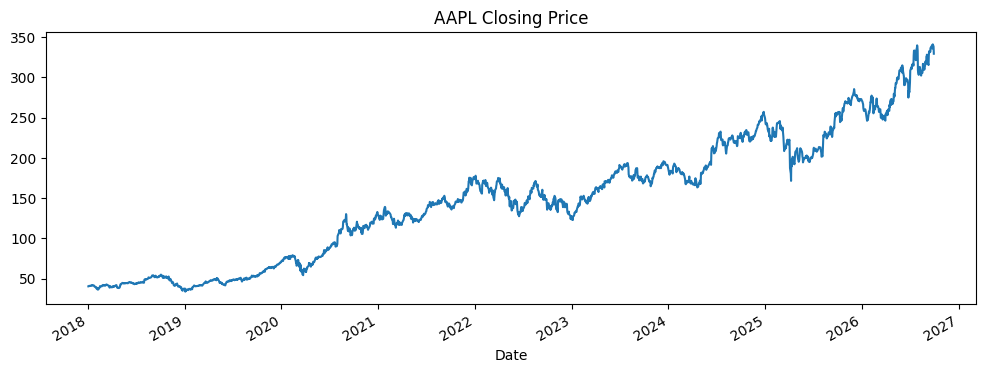

In [32]:
df["Close"].plot(figsize=(12, 4), title="AAPL Closing Price")
plt.show()

In [33]:
data = df.copy()                       # copy, so re-running this cell is safe
data["Target"] = data["Close"].shift(-1)   # next day's close
data = data.dropna()
X = data[["Open", "High", "Low", "Close", "Volume"]]
y = data["Target"]
data.to_csv("AAPL_2018_2026.csv")      # snapshot used in this project (2,196 rows incl. Target)

In [34]:
split = int(len(data) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print("Train rows:", len(X_train), "| Test rows:", len(X_test))

Train rows: 1756 | Test rows: 440


In [36]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2  :", r2_score(y_test, pred))

MAE : 3.2124692143384697
RMSE: 4.661303324812226
R2  : 0.9860178800788919


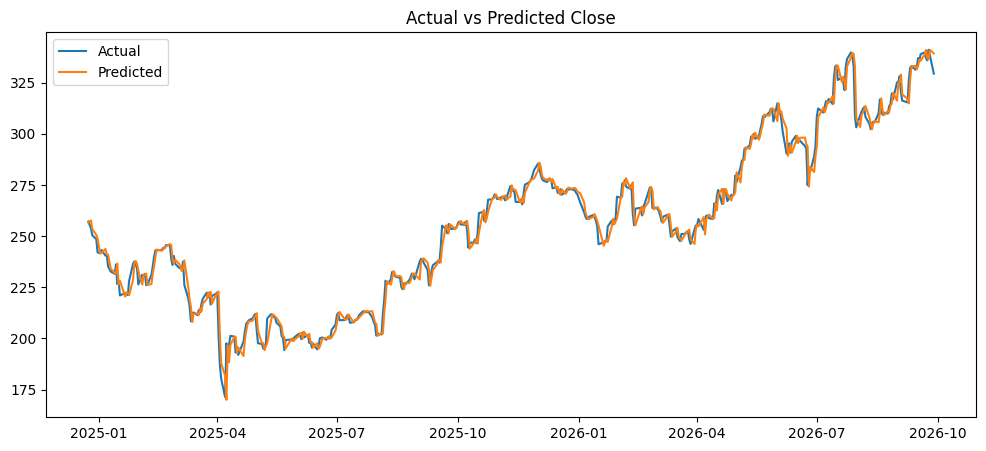

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label="Actual")
plt.plot(y_test.index, pred, label="Predicted")
plt.legend(); plt.title("Actual vs Predicted Close"); plt.show()

In [39]:
naive_pred = X_test["Close"]
print("Naive MAE :", mean_absolute_error(y_test, naive_pred))
print("Naive RMSE:", np.sqrt(mean_squared_error(y_test, naive_pred)))
print("Naive R2  :", r2_score(y_test, naive_pred))

Naive MAE : 3.137957902388139
Naive RMSE: 4.568236277142826
Naive R2  : 0.9865706371004849
